In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)
pd.set_option("display.float_format", lambda value:f"{value:,.3f}")

RANDOM_STATE = 42

RISK_ORDER = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

RISK_COLORS = {
    "Low": "#4CAF50",
    "Medium": "#FFC107",
    "High": "#FF9800",
    "Critical": "#D32F2F"
}

In [3]:
DATA_DIRECTORY = Path("../notebooks/data/raw")
OUTPUT_DIRECTORY = Path("../notebooks/data/processed")
FIGURE_DIRECTORY = Path("../notebooks/reports/figures")

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

RISK_DATA_PATH = DATA_DIRECTORY / "risk_register.csv"
CONTROL_DATA_PATH = DATA_DIRECTORY / "control_register.csv"
ACCESS_DATA_PATH = DATA_DIRECTORY / "access_activity.csv"


In [4]:
risk_raw = pd.read_csv(
    RISK_DATA_PATH,
    keep_default_na=False  # important because pandas can interpret the categorical string "None" as a missing value.
)

control_raw = pd.read_csv(
    CONTROL_DATA_PATH,
    keep_default_na=False
)

access_raw = pd.read_csv(
    ACCESS_DATA_PATH,
    keep_default_na=False
)

print("Risk Register:", risk_raw.shape)
print("Control Register:", control_raw.shape)
print("Access Activity:", access_raw.shape)

Risk Register: (5000, 32)
Control Register: (1400, 16)
Access Activity: (12000, 14)


In [5]:
risk_raw.head()

,risk_id,risk_title,risk_description,department,risk_category,asset_type,risk_owner,likelihood,impact,asset_criticality,data_sensitivity,vulnerability_count,critical_vulnerability_count,past_incident_count,policy_violation_count,audit_finding_count,third_party_dependency,number_of_controls,control_effectiveness,control_test_pass_rate,days_since_control_test,open_control_deficiencies,regulatory_relevance,treatment_status,treatment_due_days,risk_accepted,days_open,inherent_risk_score,residual_risk_score,adjusted_risk_score,risk_level,action_status
0,R00001,Cybersecurity risk affecting erp system,Potential cybersecurity event may affect the e...,Operations,Cybersecurity,ERP System,T. Karunaratne,3,4,5,4,11,0,1,3,2,0,7,0.817,0.905,50,1,GDPR,In Progress,-4,0,104,12,2.190,2.600,Low,Overdue
1,R00002,Business Continuity risk affecting database,Potential business continuity event may affect...,Operations,Business Continuity,Database,A. Perera,2,2,3,2,7,0,0,1,1,0,6,0.443,0.308,239,1,NIST CSF,Planned,-14,0,575,4,2.230,5.020,Low,Overdue
2,R00003,Cybersecurity risk affecting hr platform,Potential cybersecurity event may affect the h...,Information Technology,Cybersecurity,HR Platform,A. Perera,3,3,4,3,14,1,1,0,2,0,5,0.833,0.860,35,0,None,Risk Accepted,-95,1,615,9,1.510,2.870,Low,Open
3,R00004,Data Privacy risk affecting network infrastruc...,Potential data privacy event may affect the ne...,Sales,Data Privacy,Network Infrastructure,N. Silva,4,3,1,3,10,1,1,1,1,0,5,0.723,0.793,416,1,SOX,Not Started,68,0,85,12,3.320,4.640,Low,Open
4,R00005,Regulatory Compliance risk affecting cloud ser...,Potential regulatory compliance event may affe...,Customer Support,Regulatory Compliance,Cloud Service,S. Jayasinghe,1,1,4,4,8,2,1,1,2,1,1,0.809,0.760,466,0,ISO 27001,Planned,83,0,885,1,0.190,2.900,Low,Open


In [6]:
control_raw.head()

,control_id,control_name,control_domain,control_type,control_owner,test_frequency,automated_control,design_effectiveness,operating_effectiveness,sample_size,failed_samples,last_test_date,next_test_date,linked_risk_id,deficiency_severity,test_status
0,C0001,Incident Response Control 0001,Incident Response,Detective,R. Gunawardena,Continuous,1,Effective,Needs Improvement,10,2,2025-04-10,2025-05-10,R04132,Low,Overdue
1,C0002,Incident Response Control 0002,Incident Response,Detective,T. Karunaratne,Quarterly,0,Effective,Ineffective,40,9,2026-01-18,2026-04-18,R01913,Low,Overdue
2,C0003,Access Control Control 0003,Access Control,Preventive,M. Wijesinghe,Quarterly,0,Effective,Needs Improvement,30,11,2026-06-28,2026-09-26,R00116,Low,Scheduled
3,C0004,Access Control Control 0004,Access Control,Corrective,A. Perera,Monthly,1,Effective,Needs Improvement,20,8,2026-05-30,2026-06-29,R04925,Medium,Overdue
4,C0005,Data Protection Control 0005,Data Protection,Preventive,D. Senanayake,Continuous,0,Effective,Effective,5,0,2026-07-14,2026-08-13,R02274,None,Overdue


In [7]:
access_raw.head()

,activity_id,user_id,department,user_role,system_name,privileged_access,successful_logins,failed_logins,after_hours_events,sensitive_records_accessed,distinct_locations,primary_country,activity_timestamp,synthetic_anomaly_label
0,A000001,U0231,Sales,Standard User,HRIS,0,12,1,0,184,1,Sri Lanka,2026-08-28T22:32,0
1,A000002,U0860,Information Technology,Contractor,DEVOPS,0,9,2,0,56,1,Sri Lanka,2026-07-02T20:13,0
2,A000003,U0147,Legal,Standard User,CRM-CLOUD,0,7,3,1,92,1,India,2026-07-01T07:43,0
3,A000004,U0132,Operations,Standard User,EMAIL,0,9,1,0,13121,2,Sri Lanka,2026-08-20T19:28,1
4,A000005,U0180,Procurement,Standard User,PAYMENTS,0,12,0,1,40,1,Sri Lanka,2026-07-17T04:28,0


In [8]:
risk_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   risk_id                       5000 non-null   str    
 1   risk_title                    5000 non-null   str    
 2   risk_description              5000 non-null   str    
 3   department                    5000 non-null   str    
 4   risk_category                 5000 non-null   str    
 5   asset_type                    5000 non-null   str    
 6   risk_owner                    5000 non-null   str    
 7   likelihood                    5000 non-null   int64  
 8   impact                        5000 non-null   int64  
 9   asset_criticality             5000 non-null   int64  
 10  data_sensitivity              5000 non-null   int64  
 11  vulnerability_count           5000 non-null   int64  
 12  critical_vulnerability_count  5000 non-null   int64  
 13  past_incident_

In [9]:
# Display column names
for number, column in enumerate(risk_raw.columns, start=1):
    print(f"{number:02d}. {column}")

01. risk_id
02. risk_title
03. risk_description
04. department
05. risk_category
06. asset_type
07. risk_owner
08. likelihood
09. impact
10. asset_criticality
11. data_sensitivity
12. vulnerability_count
13. critical_vulnerability_count
14. past_incident_count
15. policy_violation_count
16. audit_finding_count
17. third_party_dependency
18. number_of_controls
19. control_effectiveness
20. control_test_pass_rate
21. days_since_control_test
22. open_control_deficiencies
23. regulatory_relevance
24. treatment_status
25. treatment_due_days
26. risk_accepted
27. days_open
28. inherent_risk_score
29. residual_risk_score
30. adjusted_risk_score
31. risk_level
32. action_status


In [10]:
# Function for data-quality

def create_quality_summary(
        dataset_name,
        dataframe,
        identifier_column
):
    summary = {
        "dataset": dataset_name,
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
        "duplicate_rows": int(
            dataframe.duplicated().sum()
        ),
        "missing_values": int(
            dataframe.isna().sum().sum()
        ),
        "blank_string_cells": int(
            dataframe
            .select_dtypes(include="object")
            .eq("")
            .sum()
            .sum()
        ),
        "unique_identifiers": int(
            dataframe[identifier_column].nunique()
        ),
        "duplicate_identifiers": int(
            dataframe[identifier_column]
            .duplicated()
            .sum()
        )
    }

    return summary

In [11]:
initial_quality_summary = pd.DataFrame([
    create_quality_summary(
        "Risk Register",
        risk_raw,
        "risk_id"
    ),
    create_quality_summary(
        "Control Register",
        control_raw,
        "control_id"
    ),
    create_quality_summary(
        "Access Activity",
        access_raw,
        "activity_id"
    )
])

initial_quality_summary

,dataset,rows,columns,duplicate_rows,missing_values,blank_string_cells,unique_identifiers,duplicate_identifiers
0,Risk Register,5000,32,0,0,0,5000,0
1,Control Register,1400,16,0,0,0,1400,0
2,Access Activity,12000,14,0,0,0,12000,0


In [12]:
# Create Column Profile

def create_column_profile(dataframe):
    profile = pd.DataFrame({
        "data_type": dataframe.dtypes.astype(str),
        "missing_count": dataframe.isna().sum(),
        "unique_values": dataframe.nunique(
            dropna=False
        )
    })

    profile["missing_percentage"] = (
        profile["missing_count"]
        / len(dataframe)
        *100
    ).round(2)

    return profile.sort_values(
        "missing_count",
        ascending=False
    )

In [13]:
risk_column_profile = create_column_profile(
    risk_raw
)

risk_column_profile

,data_type,missing_count,unique_values,missing_percentage
risk_id,str,0,5000,0.000
risk_title,str,0,72,0.000
risk_description,str,0,574,0.000
department,str,0,8,0.000
risk_category,str,0,8,0.000
asset_type,str,0,9,0.000
risk_owner,str,0,8,0.000
likelihood,int64,0,5,0.000
impact,int64,0,5,0.000
asset_criticality,int64,0,5,0.000


In [14]:
control_column_profile = create_column_profile(
    control_raw
)

control_column_profile

,data_type,missing_count,unique_values,missing_percentage
control_id,str,0,1400,0.000
control_name,str,0,1400,0.000
control_domain,str,0,8,0.000
control_type,str,0,3,0.000
control_owner,str,0,8,0.000
test_frequency,str,0,5,0.000
automated_control,int64,0,2,0.000
design_effectiveness,str,0,3,0.000
operating_effectiveness,str,0,4,0.000
sample_size,int64,0,7,0.000


In [15]:
access_column_profile = create_column_profile(
    access_raw
)

access_column_profile

,data_type,missing_count,unique_values,missing_percentage
activity_id,str,0,12000,0.000
user_id,str,0,900,0.000
department,str,0,8,0.000
user_role,str,0,8,0.000
system_name,str,0,9,0.000
privileged_access,int64,0,2,0.000
successful_logins,int64,0,96,0.000
failed_logins,int64,0,55,0.000
after_hours_events,int64,0,39,0.000
sensitive_records_accessed,int64,0,917,0.000


In [16]:
risk = risk_raw.copy()
control = control_raw.copy()
access = access_raw.copy()

In [17]:
# Clean Text Columns

# Remove leading and trailing whitespace

for dataframe in [risk, control, access]:

    text_columns = dataframe.select_dtypes(
        include="object"
    ).columns

    for column in text_columns:
        dataframe[column] = (
            dataframe[column]
            .str.strip()
        )


In [18]:
# Clean ambiguos categorical values

# Replace "None" with explicit business labels

risk["regulatory_relevance"] = (
    risk["regulatory_relevance"]
    .replace({
        "None": "Not Applicable",
        "": "Not Applicable"
    })
)

control["deficiency_severity"] = (
    control["deficiency_severity"]
    .replace({
        "None": "No Deficiency",
        "": "No Deficiency"
    })
)

In [19]:
print(
    risk["regulatory_relevance"]
    .value_counts()
)

print()

print(
    control["deficiency_severity"]
    .value_counts()
)

regulatory_relevance
Not Applicable       1115
SOX                   675
Local Privacy Law     674
GDPR                  651
PCI DSS               645
ISO 27001             629
NIST CSF              611
Name: count, dtype: int64

deficiency_severity
No Deficiency    843
Medium           208
Low              197
High             121
Critical          31
Name: count, dtype: int64


In [20]:
# Convert dates and timestamps

control["last_test_date"] = pd.to_datetime(
    control["last_test_date"],
    errors="coerce"
)

control["next_test_date"] = pd.to_datetime(
    control["next_test_date"],
    errors="coerce"
)

access["activity_timestamp"] = pd.to_datetime(
    access["activity_timestamp"],
    errors="coerce"
)

In [21]:
# Check for Conversion errors

date_validation = pd.DataFrame({
    "field": [
        "last_test_date",
        "next_test_date",
        "activity_timestamp"
    ],
    "conversion_error": [
        control["last_test_date"].isna().sum(),
        control["next_test_date"].isna().sum(),
        access["activity_timestamp"].isna().sum()
    ]

})

date_validation

,field,conversion_error
0,last_test_date,0
1,next_test_date,0
2,activity_timestamp,0


In [22]:
# Remove duplicate records 

print("Risk duplicates:", risk.duplicated().sum())
print("Control duplicates:", control.duplicated().sum())
print("Access duplicated:", access.duplicated().sum())

Risk duplicates: 0
Control duplicates: 0
Access duplicated: 0


In [23]:
# Remove duplicates

# risk = risk.drop_duplicates().copy()
# controls = control.drop_duplicates().copy()
# access = access.drop_duplicates().copy()

In [24]:
# Check duplicate identifiers

print(
    "Duplicate risk IDs:",
    risk["risk_id"].duplicated().sum()
)

print(
    "Duplicate control IDs:",
    control["control_id"].duplicated().sum()
)

print(
    "Duplicate activity IDs:",
    access["activity_id"].duplicated().sum()
)

Duplicate risk IDs: 0
Duplicate control IDs: 0
Duplicate activity IDs: 0


In [25]:
# Validate numeric ranges


range_validation = pd.DataFrame([
    {
        "field": "likelihood",
        "minimum": risk["likelihood"].min(),
        "maximum": risk["likelihood"].max(),
        "expected_range": "1 to 5",
        "invalid_records": int(
            (~risk["likelihood"].between(1, 5)).sum()
        )
    },

    {
        "field": "impact",
        "minimum": risk["impact"].min(),
        "maximum": risk["impact"].max(),
        "expected_range": "1 to 5",
        "invalid_records": int(
            (~risk["impact"].between(1, 5)).sum()
        )
    },

    {
        "field": "asset_criticality",
        "minimum": risk["asset_criticality"].min(),
        "maximum": risk["asset_criticality"].max(),
        "expected_range": "1 to 5",
        "invalid_records": int(
            (
                ~risk["asset_criticality"]
                .between(1, 5)
            ).sum()
        )
    },

    {
        "field": "data_sensitivity",
        "minimum": risk["data_sensitivity"].min(),
        "maximum": risk["data_sensitivity"].max(),
        "expected_range": "1 to 5",
        "invalid_records": int(
            (
                ~risk["data_sensitivity"]
                .between(1, 5)
            ).sum()
        )
    },

    {
        "field": "control_effectiveness",
        "minimum": risk["control_effectiveness"].min(),
        "maximum": risk["control_effectiveness"].max(),
        "expected_range": "0 to 1",
        "invalid_records": int(
            (
                ~risk["control_effectiveness"]
                .between(0, 1)
            ).sum()
        )
    },
    
    {
        "field": "control_test_pass_rate",
        "minimum": risk["control_test_pass_rate"].min(),
        "maximum": risk["control_test_pass_rate"].max(),
        "expected_range": "0 to 1",
        "invalid_records": int(
            (
                ~risk["control_test_pass_rate"]
                .between(0, 1)
            ).sum()
        )
    }
])

range_validation

,field,minimum,maximum,expected_range,invalid_records
0,likelihood,1.000,5.000,1 to 5,0
1,impact,1.000,5.000,1 to 5,0
2,asset_criticality,1.000,5.000,1 to 5,0
3,data_sensitivity,1.000,5.000,1 to 5,0
4,control_effectiveness,0.150,0.970,0 to 1,0
5,control_test_pass_rate,0.050,1.000,0 to 1,0


In [26]:
# Validate categorical values

expected_risk_levels = {
    "Low",
    "Medium",
    "High",
    "Critical"
}

unexpected_risk_levels = (
    set(risk["risk_level"].unique())
    - expected_risk_levels
)

print(
    "Unexpected risk levels:",
    unexpected_risk_levels
)

Unexpected risk levels: set()


In [27]:
# Validate treatement status:

expected_treatment_statuses = {
    "Not Started",
    "Planned",
    "In progress",
    "Implemented",
    "Risk Accepted"
}

unexpected_treatment_statuses = (
    set(risk["treatment_status"].unique())
    - expected_treatment_statuses
)

print(
    "unexpected_treatment_statuses:",
    unexpected_treatment_statuses
)

unexpected_treatment_statuses: {'In Progress'}


#### Risk Scoring Logic:

Inherent Risk = Likelihood × Impact

Residual Risk = Inherent Risk × (1 - Control Effectiveness)

In [28]:
# Validate calculated risk values

# Recalculate inherent risk:

calculated_inherent_risk = (
    risk["likelihood"] * risk["impact"]
)

inherent_risk_difference = (
    risk["inherent_risk_score"] - calculated_inherent_risk
).abs()

print(
    "Inherent risk mismatches:",
    (inherent_risk_difference > 0.001).sum()
)

Inherent risk mismatches: 0


In [30]:
# Validate calculated risk values

calculated_residual_risk = (
    calculated_inherent_risk * (1 - risk["control_effectiveness"])
)

residual_risk_difference = (
    risk["residual_risk_score"] - calculated_residual_risk
).abs()

print(
    "Residual risk mismatches:",
    (residual_risk_difference > 0.011).sum()   # The small tolerance allows for rounding differences.
)

Residual risk mismatches: 10


In [32]:
# Validate links between risks and controls


risk_ids = set(risk["risk_id"])

linked_risk_ids = set(
    control["linked_risk_id"]
)

unknown_linked_risk_ids = (
    linked_risk_ids - risk_ids
)

print(
    "Unknown linked risk IDs",
    len(unknown_linked_risk_ids)
)



Unknown linked risk IDs 0


In [33]:
# Final data-quality summary

final_quality_summary = pd.DataFrame([
    create_quality_summary(
        "Risk Register Clean",
        risk,
        "risk_id"
    ),
    create_quality_summary(
        "Control Register Clean",
        control
        ,
        "control_id"
    ),
    create_quality_summary(
        "Access Activity Clean",
        access,
        "activity_id"
    )
])

final_quality_summary

,dataset,rows,columns,duplicate_rows,missing_values,blank_string_cells,unique_identifiers,duplicate_identifiers
0,Risk Register Clean,5000,32,0,0,0,5000,0
1,Control Register Clean,1400,16,0,0,0,1400,0
2,Access Activity Clean,12000,14,0,0,0,12000,0


In [34]:
# Risk level distribution

risk_distribution = (
    risk["risk_level"]
    .value_counts()
    .reindex(RISK_ORDER)
    .fillna(0)
    .astype(int)
)

risk_distribution_summary = pd.DataFrame({
    "count": risk_distribution,
    "percentage": (risk_distribution/len(risk)*100).round(2)
})

risk_distribution_summary

,count,percentage
risk_level,,
Low,3284,65.680
Medium,1433,28.660
High,261,5.220
Critical,22,0.440


<function matplotlib.pyplot.show(close=None, block=None)>

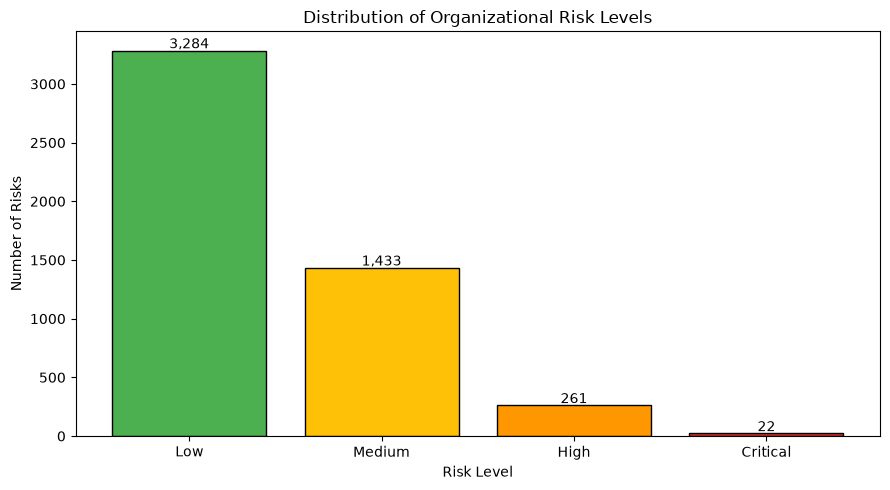

In [35]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    risk_distribution.index,
    risk_distribution.values,
    color=[
        RISK_COLORS[level]
        for level in risk_distribution.index
    ],
    edgecolor="black"
)

plt.title("Distribution of Organizational Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Risks")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20,
        f"{int(height):,}",
        ha="center"
    )

plt.tight_layout()
plt.show

In [36]:
# Department-level risk analysis

department_summary = (
    risk.groupby("department")
    .agg(
        total_risks=(
            "risk_id",
            "count"
        ),
        average_inherent_risk=(
            "inherent_risk_score",
            "mean"
        ),
        average_residual_risk=(
            "residual_risk_score",
            "mean"
        ),
        high_critical_risks=(
            "risk_level",
            lambda values: values
            .isin(["High", "Critical"])
            .sum()
        ),
        overdue_actions=(
            "action_status",
            lambda values: (
                values == "Overdue"
            ).sum()
        )
    )
    .reset_index()
)

department_summary["high_critical_rate"] = (
    department_summary["high_critical_risks"]/department_summary["total_risks"]
)

department_summary["overdue_action_rate"] = (
    department_summary["overdue_actions"]/department_summary["total_risks"]
)

department_summary.sort_values(
    "high_critical_rate",
    ascending=False
)


,department,total_risks,average_inherent_risk,average_residual_risk,high_critical_risks,overdue_actions,high_critical_rate,overdue_action_rate
0,Customer Support,510,8.996,3.021,37,145,0.073,0.284
3,Information Technology,1278,8.959,2.969,79,322,0.062,0.252
6,Procurement,389,9.224,3.115,24,108,0.062,0.278
7,Sales,478,8.699,2.891,27,125,0.056,0.262
5,Operations,782,8.592,2.799,40,217,0.051,0.277
2,Human Resources,512,8.805,2.902,25,119,0.049,0.232
1,Finance,717,8.622,2.856,35,208,0.049,0.290
4,Legal,334,8.578,2.941,16,94,0.048,0.281


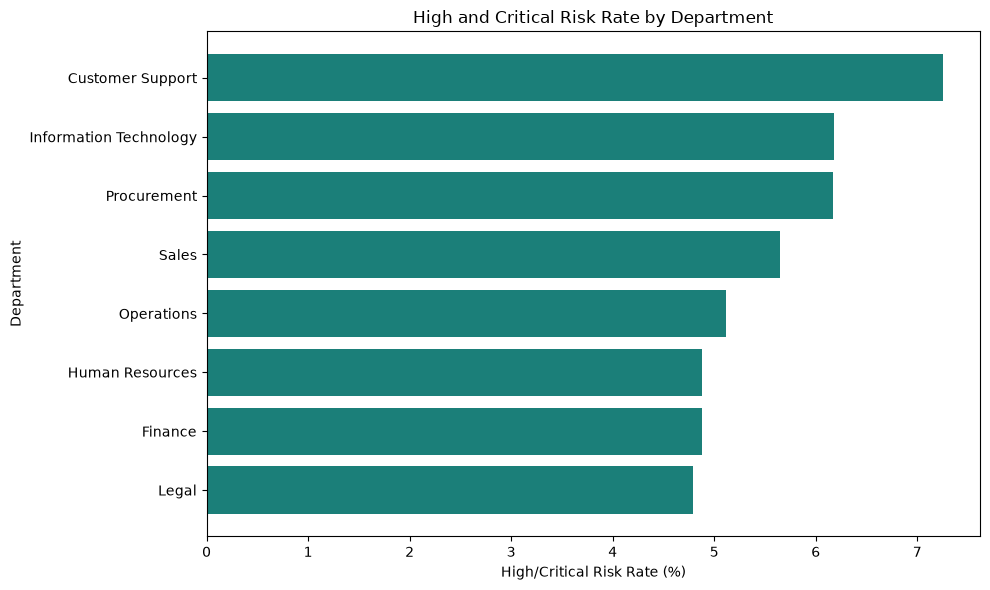

In [37]:
department_plot = (
    department_summary
    .sort_values(
        "high_critical_rate",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    department_plot["department"],
    department_plot["high_critical_rate"] * 100,
    color="#1B7F79"
)

plt.title(
    "High and Critical Risk Rate by Department"
)
plt.xlabel("High/Critical Risk Rate (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [38]:
# Risk-category analysis

category_summary = (
    risk.groupby("risk_category")
    .agg(
        total_risks=(
            "risk_id",
            "count"
        ),
        average_residual_risk=(
            "residual_risk_score",
            "mean"
        ),
        average_vulnerabilities=(
            "vulnerability_count",
            "mean"
        ),
        average_incidents=(
            "past_incident_count",
            "mean"
        ),
        average_audit_findings=(
            "audit_finding_count",
            "mean"
        ),
        average_control_deficiencies=(
            "open_control_deficiencies",
            "mean"
        ),
        high_critical_risks=(
            "risk_level",
            lambda values: values
            .isin(["High", "Critical"])
            .sum()
        )
    )
    .reset_index()
)

category_summary["high_critical_rate"] = (
    category_summary["high_critical_risks"]/category_summary["total_risks"]
)

category_summary.sort_values(
    "high_critical_rate",
    ascending=False
)

,risk_category,total_risks,average_residual_risk,average_vulnerabilities,average_incidents,average_audit_findings,average_control_deficiencies,high_critical_risks,high_critical_rate
7,Third-Party,650,3.022,6.102,0.802,1.829,1.706,52,0.080
2,Cybersecurity,611,3.336,10.208,0.795,1.702,1.702,48,0.079
6,Regulatory Compliance,578,2.919,6.033,0.753,1.692,1.766,35,0.061
3,Data Privacy,640,2.879,5.839,0.764,1.756,1.653,34,0.053
4,Financial,613,2.908,6.212,0.834,1.825,1.755,32,0.052
1,Business Continuity,625,2.787,6.032,0.734,1.803,1.651,30,0.048
5,Operational,611,2.826,6.200,0.786,1.715,1.786,27,0.044
0,Access Management,672,2.752,5.985,0.790,1.768,1.698,25,0.037


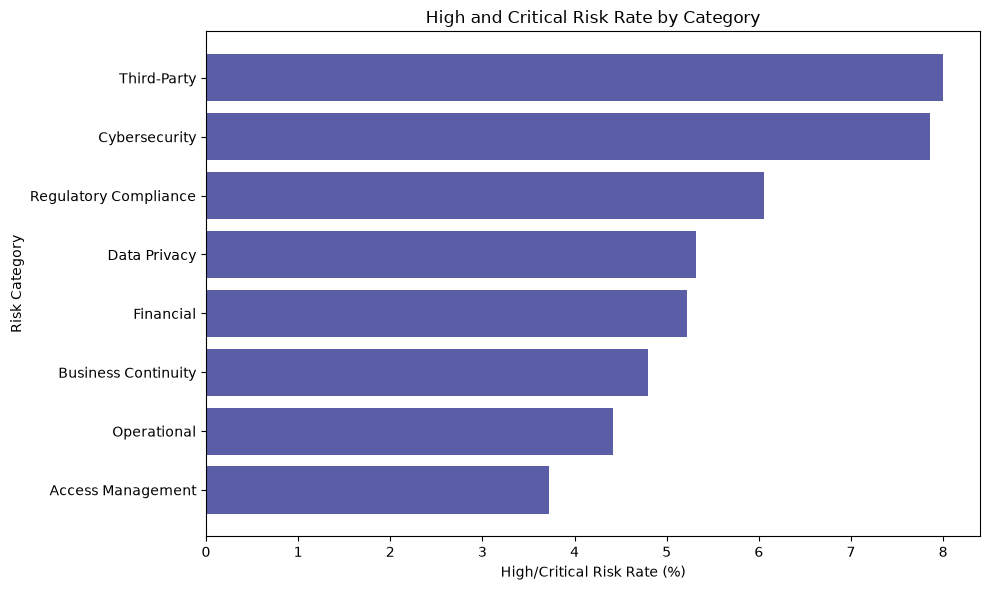

In [40]:
category_plot = (
    category_summary
    .sort_values(
        "high_critical_rate",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_plot["risk_category"],
    category_plot["high_critical_rate"] * 100,
    color="#5B5EA6"
)

plt.title(
    "High and Critical Risk Rate by Category"
)
plt.xlabel("High/Critical Risk Rate (%)")
plt.ylabel("Risk Category")

plt.tight_layout()
plt.show()

In [41]:
# Inherent versus residual risk

risk[
    [
        "inherent_risk_score",
        "residual_risk_score"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
inherent_risk_score,"5,000.000",8.812,4.421,1.000,6.000,8.000,12.000,25.000
residual_risk_score,"5,000.000",2.927,2.148,0.060,1.360,2.390,3.930,17.380


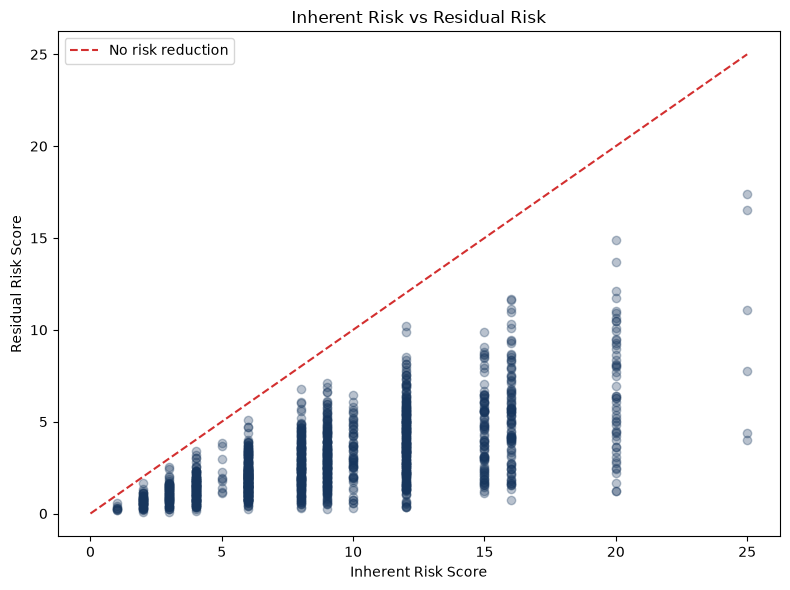

In [42]:
plot_sample = risk.sample(
    n=min(1500, len(risk)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_sample["inherent_risk_score"],
    plot_sample["residual_risk_score"],
    alpha=0.30,
    color="#17365D"
)

plt.plot(
    [0, 25],
    [0, 25],
    linestyle="--",
    color="#D32F2F",
    label="No risk reduction"
)

plt.title("Inherent Risk vs Residual Risk")
plt.xlabel("Inherent Risk Score")
plt.ylabel("Residual Risk Score")
plt.legend()

plt.tight_layout()
plt.show()

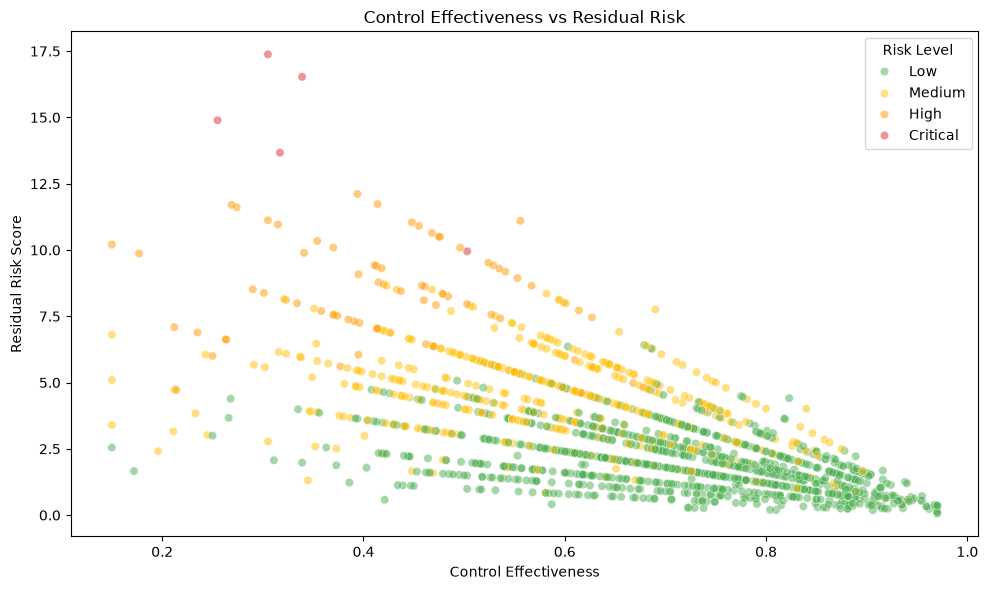

In [ ]:
# Control effectiveness Vs residual risk

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x="control_effectiveness",
    y="residual_risk_score",
    hue="risk_level",
    hue_order=RISK_ORDER,
    palette=RISK_COLORS,
    alpha=0.50
)

plt.title(
    "Control Effectiveness vs Residual Risk"
)
plt.xlabel("Control Effectiveness")
plt.ylabel("Residual Risk Score")
plt.legend(title="Risk Level")

plt.tight_layout()
plt.show()

In [ ]:
# Treatment-status analysis

treatment_summary = (
    risk.groupby("treatment_status")
    .agg(
        total_risks=(
            "risk_id",
            "count"
        ),
        high_critical_risks=(
            "risk_level",
            lambda values: values
            .isin(["High", "Critical"])
            .sum()
        ),
        overdue_actions=(
            "action_status",
            lambda values: (
                values == "Overdue"
            ).sum()
        )
    )
    .reset_index()
)

treatment_summary["overdue_rate"] = (
    treatment_summary["overdue_actions"] 
    / treatment_summary["total_risks"]
)

treatment_summary.sort_values(
    "overdue_rate",
    ascending=False
)

,treatment_status,total_risks,high_critical_risks,overdue_actions,overdue_rate
2,Not Started,780,46,331,0.424
3,Planned,937,43,392,0.418
1,In Progress,1527,93,615,0.403
0,Implemented,1264,71,0,0.000
4,Risk Accepted,492,30,0,0.000


In [45]:
# Correlation analysis

# Select meaningful numeric variables:

correlation_columns = [
    "likelihood",
    "impact",
    "asset_criticality",
    "data_sensitivity",
    "vulnerability_count",
    "critical_vulnerability_count",
    "past_incident_count",
    "policy_violation_count",
    "audit_finding_count",
    "third_party_dependency",
    "number_of_controls",
    "control_effectiveness",
    "control_test_pass_rate",
    "days_since_control_test",
    "open_control_deficiencies",
    "treatment_due_days",
    "days_open",
    "inherent_risk_score",
    "residual_risk_score",
    "adjusted_risk_score"
]

correlation_matrix = (
    risk[correlation_columns]
    .corr()
)


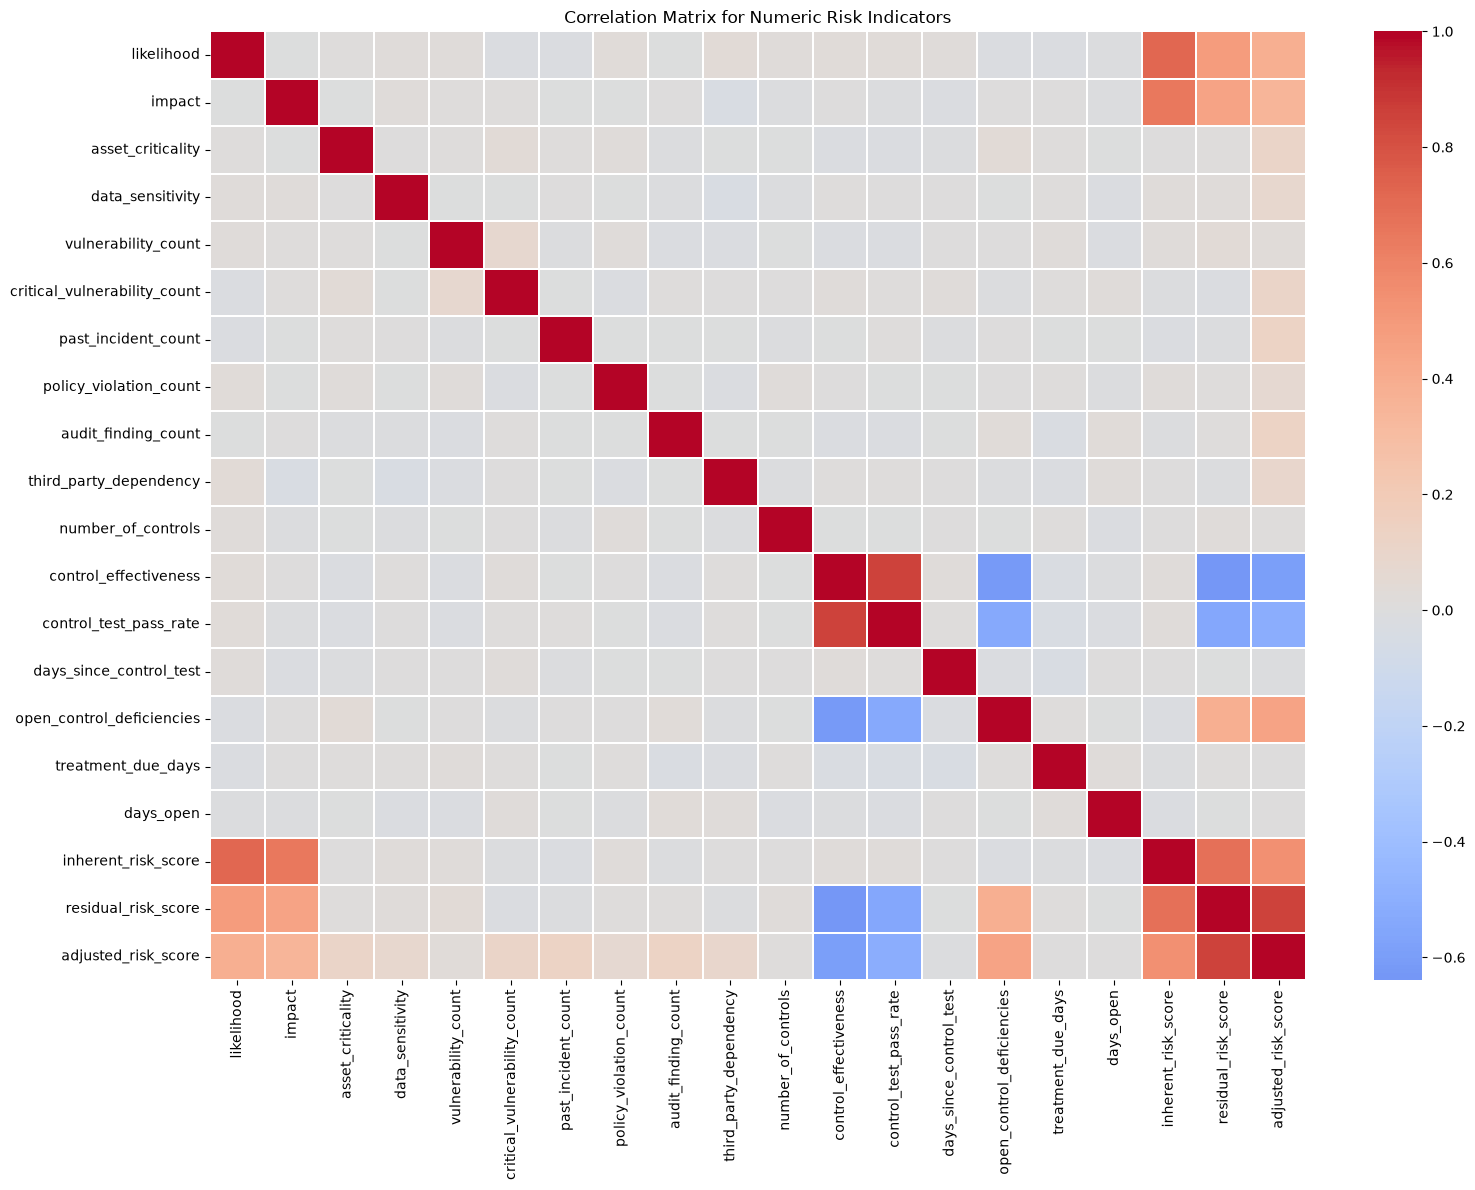

In [46]:
# Heatmap:

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.30
)

plt.title(
    "Correlation Matrix for Numeric Risk Indicators"
)

plt.tight_layout()
plt.show()

Do not use adjusted_risk_score as an ML input because it generated the target.

In [47]:
# Create control metrics:

control_summary = pd.DataFrame({
    "metric": [
        "Total controls",
        "Automated controls",
        "Overdue control tests",
        "Controls with failed samples",
        "High/Critical deficiencies"
    ],
    "value": [
        len(control),
        int(
            control["automated_control"].sum()
        ),
        int(
            (
                control["test_status"]
                == "Overdue"
            ).sum()
        ),
        int(
            (
                control["failed_samples"]
                > 0
            ).sum()
        ),
        int(
            control["deficiency_severity"]
            .isin(["High", "Critical"])
            .sum()
        )
    ]
})

control_summary

,metric,value
0,Total controls,1400
1,Automated controls,685
2,Overdue control tests,1072
3,Controls with failed samples,557
4,High/Critical deficiencies,152


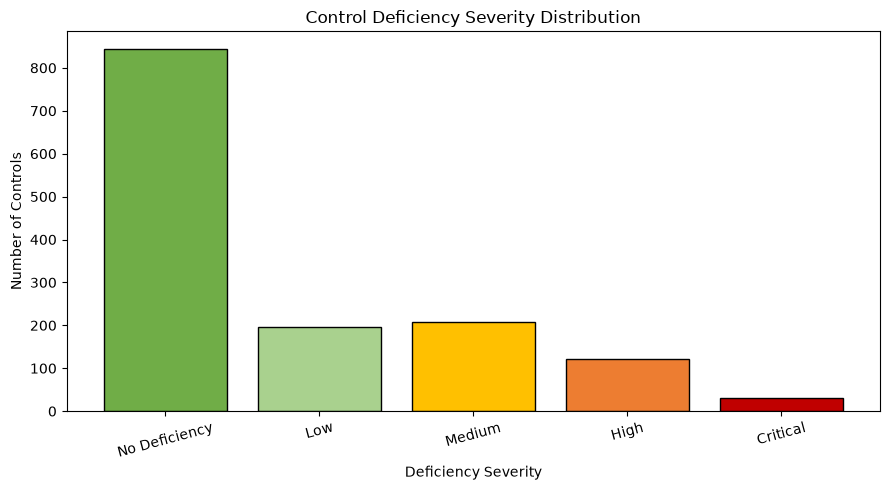

In [48]:
# Deficiency distribution:

deficiency_order = [
    "No Deficiency",
    "Low",
    "Medium",
    "High",
    "Critical"
]

deficiency_counts = (
    control["deficiency_severity"]
    .value_counts()
    .reindex(deficiency_order)
    .fillna(0)
)

plt.figure(figsize=(9, 5))

plt.bar(
    deficiency_counts.index,
    deficiency_counts.values,
    color=[
        "#70AD47",
        "#A9D18E",
        "#FFC000",
        "#ED7D31",
        "#C00000"
    ],
    edgecolor="black"
)

plt.title(
    "Control Deficiency Severity Distribution"
)
plt.xlabel("Deficiency Severity")
plt.ylabel("Number of Controls")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()